# Diabetes Project

Your task today is to **analyse** the Kaggle "Pima Indians Diabetes Database" and to **predict** whether a patient has diabetes or not, with the logistic regression you learned this week.

The task below follows the steps of a machine learning project: today you make a single pass through them, without the tuning loop you will learn in week 3.

![Today's single pass through the workflow: steps 1 to 4 (goal and metric, get the data, train-test split, explore and clean), then steps 5 to 8, where you build a random baseline, a rule-based baseline, a logistic regression and optional versions of it, and step 9, where every model is scored on the training and the test set](assets/diabetes_project_workflow.png)

# Data Description

## Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

## About this dataset
The datasets consist of several medical predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on. For the outcome class value 1 is interpreted as "tested positive for diabetes".

|Column Name| Description|
|:------------|:------------|
|Pregnancies|Number of times pregnant|
|Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
|BloodPressure|Diastolic blood pressure (mm Hg)|
|SkinThickness|Triceps skin fold thickness (mm)|
|Insulin|2-Hour serum insulin (mu U/ml)|
|BMI|Body mass index (weight in kg/(height in m)^2)|
|DiabetesPedigreeFunction| Diabetes pedigree function|
|Age| Age (years)|
|Outcome|Class variable (0 or 1) |

## Task

1. **Set your goal.**
    - **Choose your metric.** Before you model anything, decide which evaluation metric matters most for this problem, and explain why. Think about which mistake is worse for a patient: a missed diabetes case or a false alarm.
    - **Formulate a research question and three hypotheses**. The research question states what you want to find out about the patients. Each hypothesis is a statement about the data that the data can support or contradict, written in the form *"if ..., then ..."* or *"the more ..., the more ..."*. Base them on the data description above and on what you know about diabetes, not on the data itself, and note which column you will use to check each one. Write them into the table below the task.
2. **Load the data** from `data/diabetes.csv`, and take a first look at its size and columns.
3. **Split the data into a training and a test set** before you explore it. Use `train_test_split` once. Choose the size of the test set with `test_size`, use `stratify` on `Outcome`, so that both sets keep the same share of diabetes cases, and fix the `random_state`, so that you get the same split every time you run the notebook. Keep the features and the target together: the result should be two DataFrames, `df_train` and `df_test`, that both still contain the `Outcome` column. With the target in `df_train`, you can compare patients with and without diabetes while you explore. Do not look at `df_test` until step 8.
4. **Explore and clean the training set.** Work out what each column means and whether its values make sense. Some columns hide missing values as zeros: find them and decide how to handle them.

   Then **check your three hypotheses** on the cleaned training set, each with a plot and a number (for example, the share of patients with diabetes in different groups). Then back each hypothesis with a **statistical test** from the hypothesis testing session: check first whether the values are normally distributed, choose the test accordingly, and remember that you run three tests, not one. Give each hypothesis a verdict: **supported**, **contradicted** or **cannot tell yet**. Do not write "proved": a test tells you how likely the result is under the null hypothesis, and a single sample cannot prove a hypothesis. Add anything you did not expect to the "found along the way" row.


> [!IMPORTANT]
> **Keep a record of every change you make to the training data, and of the values you use.** In step 8 you apply exactly the same changes to the test set, using only information from the training data.
>
> If you fill missing values in the training set with its median, you will later fill the missing values in the test set with that **same training median**, not with its own. If you drop a column from the training set, you will drop it from the test set as well. Never calculate anything from the test data: it stands in for new patients your model has never seen, and you would not know their values in advance.

1. **Separate the features from the target, and build two baselines.** Split `df_train` into `X_train` and `y_train`; the test set stays untouched until step 8. Then build two simple models that your logistic regression has to beat:
    - a **random baseline** with [`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html), which predicts at random in the proportions of the two classes in the training set. Fix its `random_state` as well, and
    - a **rule-based baseline** that uses the column you found most strongly related to diabetes in step 4, for example *"a value above ... means diabetes"*. Choose the cut-off on the training data.
2. **Train a logistic regression** with as many features as possible: use all the columns that are left after cleaning.
3. **Optional: handle the class imbalance.** Most patients in this dataset do not have diabetes, so a model tends to miss real cases. You can try two ways to catch more of them:
    - train with `class_weight="balanced"`, which makes each diabetes case count more during training (see the [`class_weight` parameter](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)), and
    - lower the decision threshold, using `predict_proba` instead of `predict`. Choose the threshold with the training scores, never with the test set.

   **Save every model in its own variable** (for example `dummy`, `logreg` and `logreg_balanced`, and the cut-off of your rule), so that you can evaluate all of them in the last step.
4. **Prepare the test set and evaluate all models at the very end.** First apply to `df_test` the same cleaning steps you applied to the training data in step 4, with the values learned on the training data, and split it into `X_test` and `y_test`. Then calculate the **training and the test scores of every model** with your chosen metric and the other classification metrics, and collect them in **one table**: one row per model, with columns for the training and the test scores. Then compare the models: which ones beat the baselines, and how large is the difference between training and test scores? Explain what your best model gets right, and where it still makes mistakes.

> [!TIP]
> A confusion matrix makes the trade-off visible: count how many diabetes cases each version misses, and how many false alarms it raises.

## Research Question and Hypotheses

Fill in the research question and the first three columns in step 1, before you explore the data. Fill in the verdicts in step 4.

**Research question:** ...

| | Hypothesis | Column(s) to check | Verdict (supported / contradicted / cannot tell yet) |
| :-- | :-- | :-- | :-- |
| H1 | ... | ... | ... |
| H2 | ... | ... | ... |
| H3 | ... | ... | ... |
| Found along the way | ... | ... | ... |

In [363]:
# Import the libraries you need for this project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay
)

In [364]:
# read data, check null
df = pd.read_csv("data/diabetes.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [365]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [366]:
#data check
df_train, df_test = train_test_split(df, test_size=0.25, random_state=42, stratify=df["Outcome"])
print((df_train == 0).sum())

Pregnancies                  78
Glucose                       4
BloodPressure                23
SkinThickness               166
Insulin                     273
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
Outcome                     375
dtype: int64


In [367]:
#clean data
df_train = df_train.drop(columns=["SkinThickness","Insulin"])
df_train.loc[df_train["BloodPressure"] == 0, "BloodPressure"] = df_train.BloodPressure.mean().astype(int)
df_train.loc[df_train["Glucose"] == 0, "Glucose"] = df_train.Glucose.mean().astype(int)
df_train.loc[df_train["BMI"] == 0, "BMI"] = df_train.BMI.mean()
print((df_train == 0).sum())

Pregnancies                  78
Glucose                       0
BloodPressure                 0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     375
dtype: int64


In [368]:
#train split
X_train, y_train = df_train.drop(columns="Outcome"), df_train["Outcome"]
#Data scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
#Dummyclassifier model
model_rand = DummyClassifier(strategy = "uniform", random_state=42)
model_rand.fit(X_train_scaled,y_train)
#Logistic Regression
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled,y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [369]:
#rule baseline
df_train[df_train["Outcome"] == 1].sort_values(by=["Glucose"]).head(15)

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
659,3,80,82,34.2,1.292,27,1
510,12,84,72,29.7,0.297,46,1
218,5,85,74,29.0,1.224,32,1
125,1,88,30,55.0,0.496,26,1
542,10,90,85,34.9,0.825,56,1
254,12,92,62,27.6,0.926,44,1
709,2,93,64,38.0,0.674,23,1
429,1,95,82,35.0,0.233,43,1
109,0,95,85,37.4,0.247,24,1
400,4,95,64,32.0,0.161,31,1


<Axes: xlabel='Glucose', ylabel='Count'>

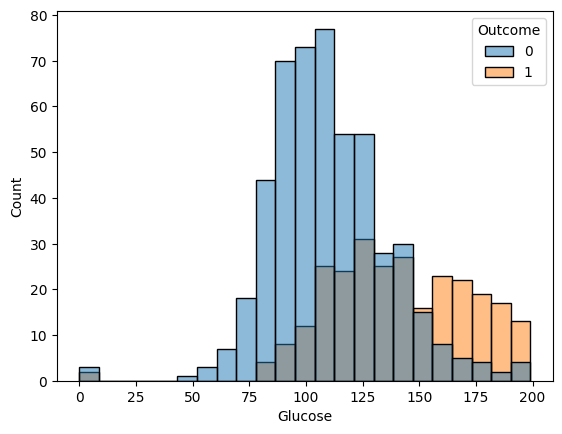

In [370]:
sns.histplot(df, x="Glucose",hue="Outcome")

In [371]:
#Model with class weight
df_train["Outcome"].value_counts()

Outcome
0    375
1    201
Name: count, dtype: int64

In [372]:
#Model with class weight
model_cw = LogisticRegression(class_weight="balanced")
model_cw.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the fol

Pregnancies 0.4375339523083439
Glucose 1.1477406070771787
BloodPressure -0.06835708938585777
BMI 0.6934242322341172
DiabetesPedigreeFunction 0.20697637126662494
Age 0.12685467509126566


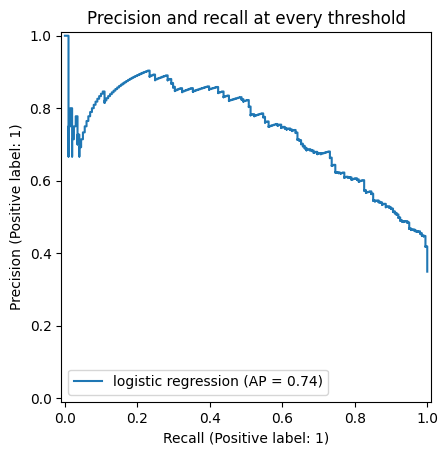

In [382]:
#Model with changed threshold
model_thr = LogisticRegression()
model_thr.fit(X_train_scaled, y_train)
proba_val_tr = model_thr.predict_proba(X_train_scaled)[:, 1]
PrecisionRecallDisplay.from_predictions(y_train, proba_val_tr, name="logistic regression")
plt.title("Precision and recall at every threshold");
for i, j in enumerate (X_train.columns,0):
    print(j, model_thr.coef_[0][i])


In [374]:
prec_v, rec_v, thresh_v = precision_recall_curve(y_train,proba_val_tr)
metrics_table = pd.DataFrame({"threshold": thresh_v, "recall": rec_v[:-1]})
thresh_max, rec_max = metrics_table[metrics_table["recall"] >= 0.7].max()

In [375]:
#test data: clean and split
df_test = df_test.drop(columns=["SkinThickness","Insulin"])
df_test.loc[df_test["BloodPressure"] == 0, "BloodPressure"] = df_test.BloodPressure.mean().astype(int)
df_test.loc[df_test["Glucose"] == 0, "Glucose"] = df_test.Glucose.mean().astype(int)
df_test.loc[df_test["BMI"] == 0, "BMI"] = df_test.BMI.mean()
print((df_test == 0).sum())
X_test, y_test = df_test.drop(columns="Outcome"), df_test["Outcome"]
X_test_scaled = scaler.transform(X_test)

Pregnancies                  33
Glucose                       0
BloodPressure                 0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     125
dtype: int64


,model,accuracy,recall,presicion,f2-score
0,Random baseline,0.438,0.418,0.289,0.384
1,Logistic regression,0.719,0.507,0.618,0.526
2,Rule base,0.667,0.866,0.513,0.761
3,Logistic regression with class weights,0.740,0.687,0.613,0.671
4,Logistic regression with chanegd threshold,0.740,0.657,0.620,0.649


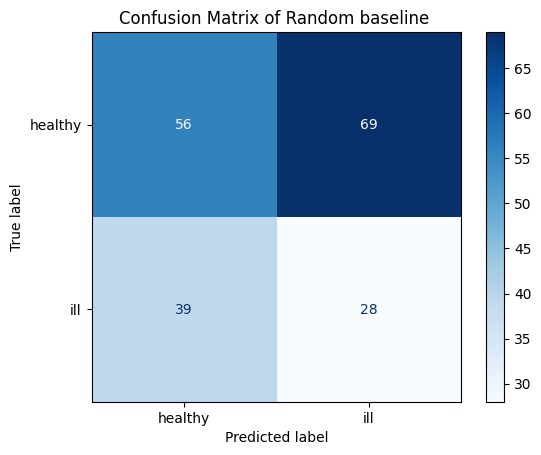

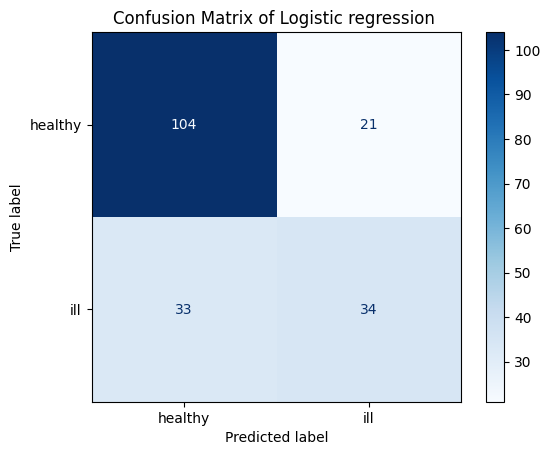

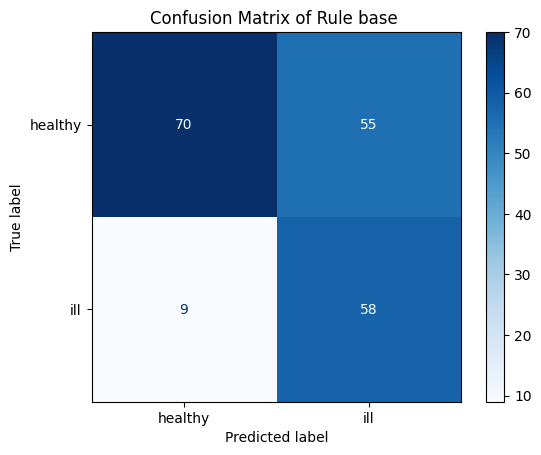

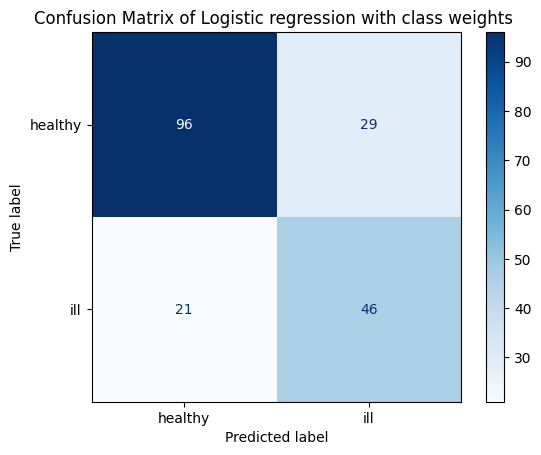

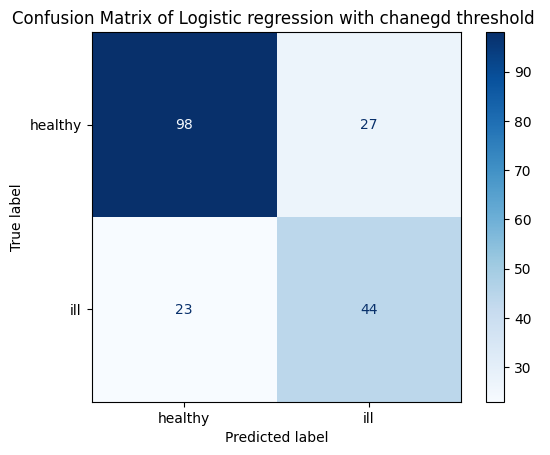

In [376]:
#evaluate models

def evaluate_model(y_test, y_pred, model_name):
    recall = recall_score(y_test, y_pred)
    presicion = precision_score(y_test, y_pred)
    f2 = fbeta_score(y_test,y_pred, beta = 2)
    accuracy = accuracy_score(y_test, y_pred)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["healthy", "ill"], cmap="Blues"
    )
    plt.title(f"Confusion Matrix of {model_name} ")
    return ({"model":model_name,
            "accuracy":accuracy, 
            "recall": recall, 
            "presicion": presicion, 
            "f2-score":f2})

#Dummyclassifier
y_pred_rand = model_rand.predict(X_test_scaled)
results=[evaluate_model(y_test, y_pred_rand, "Random baseline")]
#Logistic regression
y_pred_lr = model_lr.predict(X_test_scaled)
results.append(evaluate_model(y_test, y_pred_lr, "Logistic regression"))
#Rule-based regression 
y_pred_rule = (X_test["Glucose"] >= 110).astype(int)
results.append(evaluate_model(y_test, y_pred_rule, "Rule base"))
#Model with class weight
y_pred_cw = model_cw.predict(X_test_scaled)
results.append(evaluate_model(y_test, y_pred_cw, "Logistic regression with class weights"))
#Model with changed threshold
y_pred_thresh = (model_thr.predict_proba(X_test_scaled)[:,1] >= thresh_max).astype(int)
results.append(evaluate_model(y_test, y_pred_thresh, "Logistic regression with chanegd threshold"))
pd.DataFrame(results).round(3)